

# CAPSTONE PROJECT
# PPE COMPLIANCE MONITOR
## Thrive Plus Advanced ML & AI · Module 3: Computer Vision · CNNs
## Group 5
**Names** 
- Martha Afful
- Michael Douglas Martey
- Regina Robertson (Group leader)
- Sandra Ohenewaa Djan
- Edward Asare Ansa
- Amoah Akolbila Yakubu
- Yusif Mohammed Yakubu
- Seth Dampson



## Setup & Imports

%pip -q install matplotlib seaborn
%pip install tensorflow
%pip install h5py

In [1]:
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import matplotlib.pyplot as plt
from tensorflow import keras
from collections import Counter
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import seaborn as sns
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import yaml
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: []


## Part 1: Load & Explore Data

In [2]:
label_dir = r"C:\Users\USER\OneDrive\Desktop\THRIVE\Capstone Project\PPE DATASET\labels"

counts = Counter()

# Count all class IDs
for root, _, files in os.walk(label_dir):
    for file in files:
        if file.endswith(".txt"):
            file_path = os.path.join(root, file)

            with open(file_path, "r") as f:
                for line in f:
                    if line.strip():
                        cls = int(line.split()[0])
                        counts[cls] += 1

# Dataset mapping 
class_names = {
    0: "helmet",
    1: "gloves",
    2: "vest",
    3: "boots",
    4: "goggles",
    5: "none",
    6: "person",
    7: "no_helmet",
    8: "no_goggles",
    9: "no_gloves",
    10: "no_boots"
}

print("===== FULL PPE CLASS DISTRIBUTION =====\n")

for cls_id in sorted(counts.keys()):
    name = class_names.get(cls_id, "unknown")
    print(f"{name} (class {cls_id}): {counts[cls_id]}")

===== FULL PPE CLASS DISTRIBUTION =====

helmet (class 0): 1750
gloves (class 1): 1461
vest (class 2): 1632
boots (class 3): 1613
goggles (class 4): 526
none (class 5): 800
person (class 6): 2265
no_helmet (class 7): 485
no_goggles (class 8): 411
no_gloves (class 9): 556
no_boots (class 10): 115


In [3]:
# ======================
# PATHS
# ======================
BASE_DIR = r"C:\Users\USER\OneDrive\Desktop\THRIVE\Capstone Project\PPE DATASET"
IMG_DIR  = os.path.join(BASE_DIR, "images")
LABEL_DIR = os.path.join(BASE_DIR, "labels")

TRAIN_DIR = os.path.join(IMG_DIR, "train")
VAL_DIR   = os.path.join(IMG_DIR, "val")
TEST_DIR  = os.path.join(IMG_DIR, "test")

# ======================
# CLASS IDS
# ======================
HELMET_CLASS = 0
NO_HELMET_CLASS = 7

def get_label(label_path):
    """
    1 = COMPLIANT (Helmet)
    0 = NON-COMPLIANT (No Helmet)
    """

    if not os.path.exists(label_path):
        return None

    has_helmet = False
    has_no_helmet = False

    with open(label_path, "r") as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])

                if cls == HELMET_CLASS:
                    has_helmet = True
                if cls == NO_HELMET_CLASS:
                    has_no_helmet = True

    if has_helmet:
        return 1
    elif has_no_helmet:
        return 0
    else:
        return None

In [4]:
def load_data(image_folder, split_name):
    images = []
    labels = []

    for fname in sorted(os.listdir(image_folder)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(image_folder, fname)
            label_path = os.path.join(
                LABEL_DIR,
                split_name,
                fname.rsplit(".", 1)[0] + ".txt"
            )

            label = get_label(label_path)

            # skip if no label
            if label is None:
                continue

            try:
                img = load_img(img_path, target_size=(128, 128))
                img = img_to_array(img)

                images.append(img)
                labels.append(label)

            except Exception:
                continue

    return np.array(images), np.array(labels)

print("Loading dataset...")

x_train, y_train = load_data(TRAIN_DIR, "train")
x_val, y_val     = load_data(VAL_DIR, "val")
x_test, y_test   = load_data(TEST_DIR, "test")

print("\n===== DATA CHECK =====")

print("Train:", x_train.shape, y_train.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

print("\nClass distribution:")
print("Train - Helmet:", (y_train==1).sum(), "| No Helmet:", (y_train==0).sum())
print("Val   - Helmet:", (y_val==1).sum(), "| No Helmet:", (y_val==0).sum())
print("Test  - Helmet:", (y_test==1).sum(), "| No Helmet:", (y_test==0).sum())


Loading dataset...

===== DATA CHECK =====
Train: (1060, 128, 128, 3) (1060,)
Val: (134, 128, 128, 3) (134,)
Test: (134, 128, 128, 3) (134,)

Class distribution:
Train - Helmet: 830 | No Helmet: 230
Val   - Helmet: 107 | No Helmet: 27
Test  - Helmet: 110 | No Helmet: 24


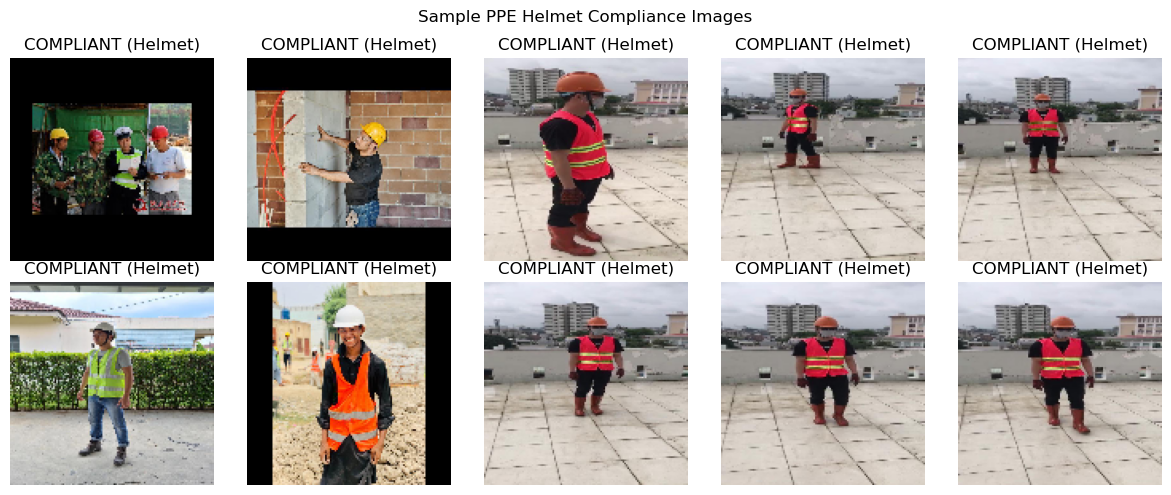

>> What to observe:
COMPLIANT = worker wearing helmet (class 1)
NON-COMPLIANT = worker without helmet (class 0)
Images are resized for CNN training (e.g., 128x128).
Next step: build CNN model for helmet compliance detection.


In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(10):
    ax = axes.flat[i]

    # display image
    ax.imshow(x_train[i].astype('uint8'))

    # label mapping (binary classification)
    label = 'COMPLIANT (Helmet)' if y_train[i] == 1 else 'NON-COMPLIANT (No Helmet)'

    ax.set_title(label)
    ax.axis('off')

plt.suptitle('Sample PPE Helmet Compliance Images')
plt.tight_layout()
plt.show()

print('>> What to observe:')
print('COMPLIANT = worker wearing helmet (class 1)')
print('NON-COMPLIANT = worker without helmet (class 0)')
print('Images are resized for CNN training (e.g., 128x128).')
print('Next step: build CNN model for helmet compliance detection.')

## Part 2: Preprocessing

Normalize pixel values and prepare for training.

In [6]:
# Normalize images to [0, 1]
x_train_norm = x_train / 255.0
x_val_norm   = x_val / 255.0
x_test_norm  = x_test / 255.0

print("Train:", len(x_train_norm), "images")
print("Validation:", len(x_val_norm), "images")
print("Test:", len(x_test_norm), "images")

print("Data normalized to [0, 1]")

Train: 1060 images
Validation: 134 images
Test: 134 images
Data normalized to [0, 1]


## Part 3: Model A — CNN from Scratch

### Step 1: Define Architecture

In [7]:

model_scratch = keras.Sequential([

    # ======================
    # Block 1
    # ======================
    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # ======================
    # Block 2
    # ======================
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # ======================
    # Flatten + Dense layers
    # ======================
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # ======================
    # Output layer (Binary Classification)
    # ======================
    layers.Dense(1, activation='sigmoid')
])

model_scratch.summary()

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,408,257 (32.07 MB)

 Trainable params: 8,408,257 (32.07 MB)

 Non-trainable params: 0 (0.00 B)

### Step 2: Compile

In [8]:
# Compile the CNN model for binary classification (Helmet vs No Helmet)

model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Step 3: Train

In [9]:
print("Training CNN for PPE Helmet Compliance Detection...")

history_scratch = model_scratch.fit(
    x_train_norm, y_train,              # training data
    validation_data=(x_val_norm, y_val), # validation data
    epochs=15,
    batch_size=32,
    verbose=1
)

Training CNN for PPE Helmet Compliance Detection...
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 316ms/step - accuracy: 0.7868 - loss: 0.4551 - val_accuracy: 0.7985 - val_loss: 0.3468
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step - accuracy: 0.8528 - loss: 0.3169 - val_accuracy: 0.8284 - val_loss: 0.2847
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 299ms/step - accuracy: 0.8991 - loss: 0.2280 - val_accuracy: 0.8731 - val_loss: 0.2428
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.9406 - loss: 0.1526 - val_accuracy: 0.9328 - val_loss: 0.1827
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 309ms/step - accuracy: 0.9802 - loss: 0.0815 - val_accuracy: 0.9478 - val_loss: 0.1742
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 0.9925 - loss: 0.0492 - val_accuracy: 0.9403 - val_loss: 0.1779
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 337ms/step - accuracy: 0.9868 - loss: 0.0423 - val_accuracy: 0.9030 - val_loss: 0.2282
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 304

### Step 4: Evaluate on Test Set

In [10]:
# Evaluate on test set
test_loss_scratch, test_acc_scratch = model_scratch.evaluate(
    x_test_norm, y_test,
    verbose=0
)

print(f"Test Loss: {test_loss_scratch:.7f}")
print(f"Test Accuracy: {test_acc_scratch:.7f}")

# Predict probabilities
y_pred_scratch = model_scratch.predict(x_test_norm, verbose=0)

# Convert probabilities to binary classes
y_pred_scratch_binary = (y_pred_scratch > 0.5).astype(np.int32).flatten()

Test Loss: 0.5787916
Test Accuracy: 0.9029851


### Confusion Matrix

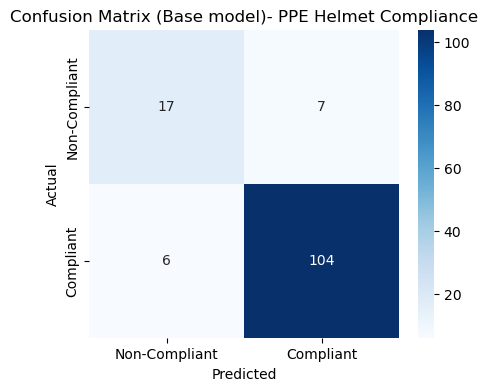

In [11]:
cm1 = confusion_matrix(y_test, y_pred_scratch_binary)

plt.figure(figsize=(5,4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Compliant', 'Compliant'],
            yticklabels=['Non-Compliant', 'Compliant'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Base model)- PPE Helmet Compliance')
plt.show()

### Classification Report

In [12]:
print("===== CLASSIFICATION REPORT =====")
print(classification_report(
    y_test,
    y_pred_scratch_binary,
    target_names=['Non-Compliant (No Helmet)', 'Compliant (Helmet)']
))

===== CLASSIFICATION REPORT =====
                           precision    recall  f1-score   support

Non-Compliant (No Helmet)       0.74      0.71      0.72        24
       Compliant (Helmet)       0.94      0.95      0.94       110

                 accuracy                           0.90       134
                macro avg       0.84      0.83      0.83       134
             weighted avg       0.90      0.90      0.90       134



## Implementing Data Augmentation

In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

### Handling Class Imbalance using class weights



In [20]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Manually tuned weights 
class_weights = {0: 1.2, 1: 1.0}

print("Using Class Weights:", class_weights)

Using Class Weights: {0: 1.2, 1: 1.0}


### Retraining the model

In [21]:
history_aug = model_scratch.fit(
    x_train_norm, y_train,
    validation_data=(x_val_norm, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step - accuracy: 1.0000 - loss: 5.2922e-04 - val_accuracy: 0.9104 - val_loss: 0.3665
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 1.0000 - loss: 4.8885e-04 - val_accuracy: 0.9328 - val_loss: 0.3961
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 297ms/step - accuracy: 1.0000 - loss: 4.1108e-04 - val_accuracy: 0.9179 - val_loss: 0.3613
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step - accuracy: 1.0000 - loss: 8.2605e-04 - val_accuracy: 0.9254 - val_loss: 0.3713
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 1.0000 - loss: 3.8613e-04 - val_accuracy: 0.9328 - val_loss: 0.4118
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 1.0000 - loss: 2.3732e-04 - val_accuracy: 0.9328 - val_loss: 0.4023
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 314ms/step - accuracy: 1.0000 - loss: 7.8397e-05 - val_accuracy: 0.9328 - val_loss: 0.4109
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 1.00

In [22]:
# Evaluate on test set (Improved CNN with Class Weights)
test_loss_aug, test_acc_aug = model_scratch.evaluate(
    x_test_norm, y_test,
    verbose=0
)


print(f"Test Loss (Class weights): {test_loss_aug:.7f}")
print(f"Test Accuracy (Class weights): {test_acc_aug:.7f}")

Test Loss (Class weights): 0.7621432
Test Accuracy (Class weights): 0.8805970


### Data Augmentation: Classification Report

In [23]:
y_pred = model_scratch.predict(x_test_norm)
y_pred_classes = (y_pred > 0.6).astype(int)

print(classification_report(y_test, y_pred_classes,
      target_names=["Non-Compliant", "Compliant"]))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
               precision    recall  f1-score   support

Non-Compliant       0.81      0.54      0.65        24
    Compliant       0.91      0.97      0.94       110

     accuracy                           0.90       134
    macro avg       0.86      0.76      0.79       134
 weighted avg       0.89      0.90      0.89       134



### Data Augmentation: Confusion Matrix

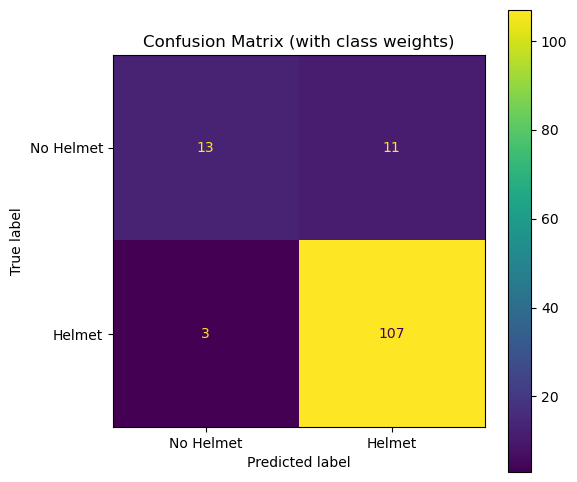

In [24]:
cm2 = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(cm2, display_labels=["No Helmet", "Helmet"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix (with class weights)")
plt.show()

### STRATEGY: OVERSAMPLING + AUGMENTATION

STEP 1: Separate Classes

In [33]:
# Separate indices
no_helmet_idx = np.where(y_train == 0)[0]
helmet_idx = np.where(y_train == 1)[0]

# Split data
x_no_helmet = x_train_norm[no_helmet_idx]
y_no_helmet = y_train[no_helmet_idx]

x_helmet = x_train_norm[helmet_idx]
y_helmet = y_train[helmet_idx]

print("Original counts:")
print("No Helmet:", len(x_no_helmet))
print("Helmet:", len(x_helmet))

Original counts:
No Helmet: 230
Helmet: 830


STEP 2: Oversample Minority Class (No helmet)

In [34]:
# Oversample No Helmet to match Helmet class
oversample_factor = len(x_helmet) // len(x_no_helmet)

x_no_helmet_oversampled = np.repeat(x_no_helmet, oversample_factor, axis=0)
y_no_helmet_oversampled = np.repeat(y_no_helmet, oversample_factor, axis=0)

STEP 3: Combine Back

In [35]:
x_train_balanced = np.concatenate([x_helmet, x_no_helmet_oversampled], axis=0)
y_train_balanced = np.concatenate([y_helmet, y_no_helmet_oversampled], axis=0)

# Shuffle
shuffle_idx = np.random.permutation(len(x_train_balanced))
x_train_balanced = x_train_balanced[shuffle_idx]
y_train_balanced = y_train_balanced[shuffle_idx]

print("Balanced counts:")
print("Total:", len(y_train_balanced))

Balanced counts:
Total: 1520


Step 4: Adding Augmentation

In [36]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

STEP 5: Train Model (NO CLASS WEIGHTS)

In [37]:
train_generator = train_datagen.flow(
    x_train_balanced, y_train_balanced,
    batch_size=32
)

history_over = model_scratch.fit(
    train_generator,
    validation_data=(x_val_norm, y_val),
    epochs=15,
    verbose=1
)

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 389ms/step - accuracy: 0.9664 - loss: 0.0836 - val_accuracy: 0.9552 - val_loss: 0.0781
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 391ms/step - accuracy: 0.9645 - loss: 0.0940 - val_accuracy: 0.9478 - val_loss: 0.0794
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 385ms/step - accuracy: 0.9724 - loss: 0.0808 - val_accuracy: 0.9701 - val_loss: 0.0870
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 385ms/step - accuracy: 0.9730 - loss: 0.0824 - val_accuracy: 0.9478 - val_loss: 0.1290
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 383ms/step - accuracy: 0.9737 - loss: 0.0681 - val_accuracy: 0.9701 - val_loss: 0.0673
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 18s 379ms/step - accuracy: 0.9776 - loss: 0.0754 - val_accuracy: 0.9701 - val_loss: 0.0788
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 408ms/step - accuracy: 0.9737 - loss: 0.0725 - val_accuracy: 0.9776 - val_loss: 0.0661
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 383ms/step - accuracy: 0.9783 - loss: 0.0691 - val_accu

STEP 6: Evaluate

In [38]:
# Evaluate on test set (Oversampling model)
test_loss_over, test_acc_over = model_scratch.evaluate(
    x_test_norm, y_test,
    verbose=0
)


print(f"Test Loss (Oversampling): {test_loss_over:.7f}")
print(f"Test Accuracy (Oversampling): {test_acc_over:.7f}")

Test Loss (Oversampling): 0.3492490
Test Accuracy (Oversampling): 0.9253731


In [39]:
y_pred = model_scratch.predict(x_test_norm)
y_pred_oversampling = (y_pred > 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred_oversampling,
    target_names=["Non-Compliant", "Compliant"]
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
               precision    recall  f1-score   support

Non-Compliant       0.77      0.83      0.80        24
    Compliant       0.96      0.95      0.95       110

     accuracy                           0.93       134
    macro avg       0.87      0.89      0.88       134
 weighted avg       0.93      0.93      0.93       134



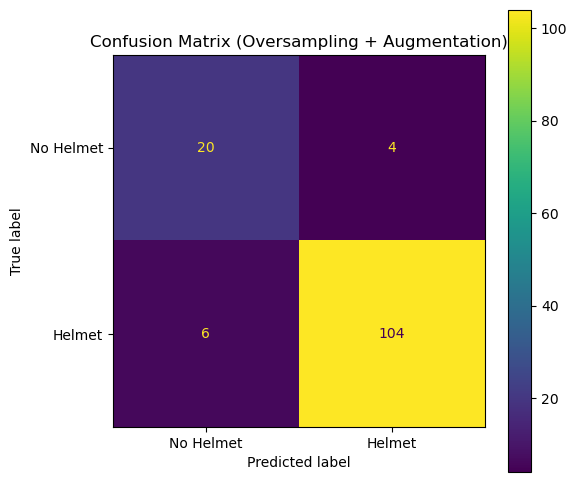

In [40]:
# Generate confusion matrix
cm3 = confusion_matrix(y_test, y_pred_oversampling)

# Display it
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm3,
    display_labels=["No Helmet", "Helmet"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix (Oversampling + Augmentation)")
plt.show()

### Combined Confusion Matrix (3 in 1)

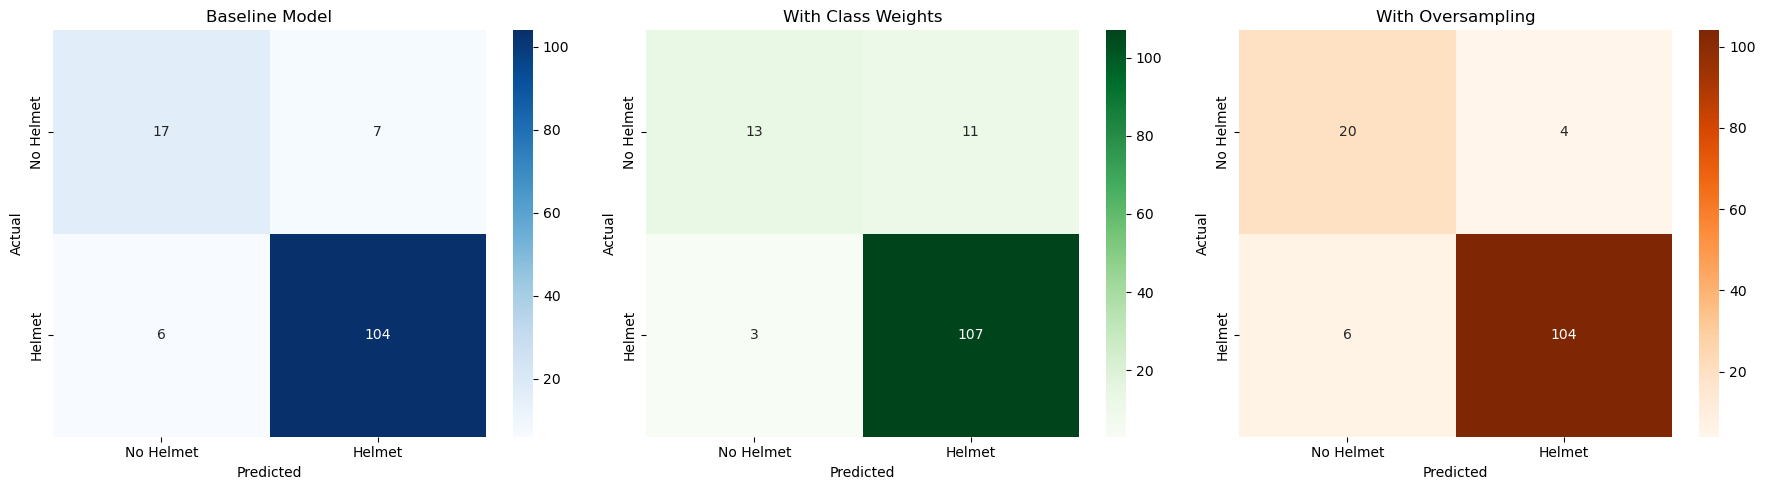

In [41]:
# --- Compute confusion matrices ---
cm1 = confusion_matrix(y_test, y_pred_scratch_binary)
cm2 = confusion_matrix(y_test, y_pred_classes)          # class weights
cm3 = confusion_matrix(y_test, y_pred_oversampling)       # oversampling 

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    "Baseline Model",
    "With Class Weights",
    "With Oversampling"
]

cms = [cm1, cm2, cm3]

cmaps = ['Blues', 'Greens', 'Oranges']

for i, ax in enumerate(axes):
    sns.heatmap(cms[i],
                annot=True,
                fmt='d',
                cmap=cmaps[i],   
                ax=ax,
                xticklabels=['No Helmet', 'Helmet'],
                yticklabels=['No Helmet', 'Helmet'])
    
    ax.set_title(titles[i])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# **Transfer Learning with MobileNetV2 for PPE Detection**

### Step 1: Resize & Preprocess for MobileNetV2

In [50]:
from skimage.transform import resize

print("Resizing images to 224×224...")

def resize_images(x):
    return np.array([resize(img, (224, 224), preserve_range=True) for img in x]).astype(np.float32)

x_train_resized = resize_images(x_train_balanced)
x_val_resized = resize_images(x_val)
x_test_resized = resize_images(x_test_norm)

print("Train shape:", x_train_resized.shape)
print("Val shape:", x_val_resized.shape)
print("Test shape:", x_test_resized.shape)


Resizing images to 224×224...
Train shape: (1520, 224, 224, 3)
Val shape: (134, 224, 224, 3)
Test shape: (134, 224, 224, 3)


Step 2: Preprocessing

In [51]:
print("Applying MobileNetV2 preprocessing...")

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

x_train_processed = mobilenet_preprocess(x_train_resized * 255)
x_val_processed   = mobilenet_preprocess(x_val_resized * 255)
x_test_processed  = mobilenet_preprocess(x_test_resized * 255)

print(f"Processed pixel range: [{x_train_processed.min():.1f}, {x_train_processed.max():.1f}]")

Applying MobileNetV2 preprocessing...
Processed pixel range: [-1.0, 1.0]


Step 3: Load MobileNetV2

In [52]:
print("Loading MobileNetV2 (pretrained on ImageNet)...")

from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print(f"Base model layers: {len(base_model.layers)}")
print(f"Total parameters: {base_model.count_params():,}")

Loading MobileNetV2 (pretrained on ImageNet)...
Base model layers: 154
Total parameters: 2,257,984


Step 4: Freezing the Base Model

In [53]:
print("Freezing the base model...")

for layer in base_model.layers:
    layer.trainable = False


print(f"Base model trainable: {base_model.trainable}")
print(f"Number of trainable parameters in base: {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}")

Freezing the base model...
Base model trainable: True
Number of trainable parameters in base: 0


In [54]:
trainable_layers = [layer for layer in base_model.layers if layer.trainable]
print("Trainable layers in base model:", len(trainable_layers))

Trainable layers in base model: 0


### Step 5 Add Custom Head

In [55]:
from tensorflow.keras import layers, models

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)  
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)           # less aggressive than 0.5
output = layers.Dense(1, activation='sigmoid')(x)

model_mobilenet = models.Model(inputs=base_model.input, outputs=output)
#model_mobilenet .summary()

### Step 6: Compile

In [56]:
# Use a LOW learning rate for transfer learning
#model_mobilenet.compile(
 #   optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  #  loss='binary_crossentropy',
   # metrics=['accuracy']
#)

from tensorflow.keras.optimizers import Adam

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Step 7: Train

In [57]:
print("Training transfer learning model")

history_mobilenet = model_mobilenet.fit(
    x_train_processed, y_train_balanced,
    validation_data=(x_val_processed, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

Training transfer learning model
Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 57s 873ms/step - accuracy: 0.7882 - loss: 0.4460 - val_accuracy: 0.5896 - val_loss: 0.6690
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 74s 711ms/step - accuracy: 0.9257 - loss: 0.1892 - val_accuracy: 0.7239 - val_loss: 0.5810
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 752ms/step - accuracy: 0.9730 - loss: 0.1087 - val_accuracy: 0.7388 - val_loss: 0.5628
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 39s 700ms/step - accuracy: 0.9809 - loss: 0.0831 - val_accuracy: 0.7537 - val_loss: 0.5636
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 35s 719ms/step - accuracy: 0.9882 - loss: 0.0597 - val_accuracy: 0.7687 - val_loss: 0.5767
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 350s 844ms/step - accuracy: 0.9954 - loss: 0.0442 - val_accuracy: 0.7761 - val_loss: 0.5979
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 35s 733ms/step - accuracy: 0.9961 - loss: 0.0386 - val_accuracy: 0.7761 - val_loss: 0.6215
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 799ms/step - accuracy

### Step 8: Evaluate

In [58]:
test_loss_transfer, test_acc_transfer = model_mobilenet.evaluate(x_test_processed, y_test, verbose=0)
print(f"Test Accuracy (before tuning): {test_acc_transfer:.4f}")

Test Accuracy (before tuning): 0.9776


### Fine-tune the model

In [59]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune = model_mobilenet.fit(
    x_train_processed,
    y_train_balanced,
    validation_data=(x_val_processed, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)


Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9803 - loss: 0.0702 - val_accuracy: 0.7910 - val_loss: 0.6785
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.9954 - loss: 0.0407 - val_accuracy: 0.7985 - val_loss: 0.7345
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9993 - loss: 0.0230 - val_accuracy: 0.7910 - val_loss: 0.7729
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 45s 942ms/step - accuracy: 0.9993 - loss: 0.0188 - val_accuracy: 0.7985 - val_loss: 0.7921
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 914ms/step - accuracy: 0.9993 - loss: 0.0155 - val_accuracy: 0.8060 - val_loss: 0.7961


### FINAL Evaluation

In [68]:
test_loss, test_acc = model_mobilenet.evaluate(x_test_processed, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = model_mobilenet.predict(x_test_processed)
y_pred_binary = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 556ms/step - accuracy: 0.9851 - loss: 0.0370
Test Loss: 0.0370
Test Accuracy: 0.9851
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 519ms/step


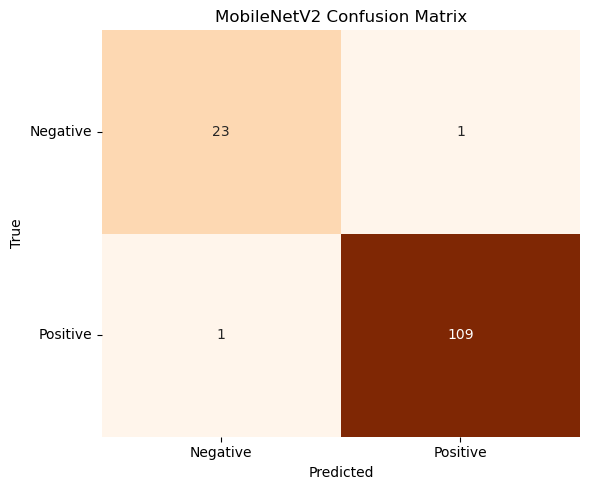

In [61]:
# Generate predictions
y_pred_mobilenet = model_mobilenet.predict(x_test_processed, verbose=0)

# Convert to binary (0 or 1)
y_pred_mobilenet_binary = (y_pred_mobilenet > 0.5).astype(int).flatten()


# Confusion matrix
cm_mobilenet = confusion_matrix(y_test, y_pred_mobilenet_binary)

# Create figure and axes 
fig, axes = plt.subplots(1, 1, figsize=(6, 5))  # single plot

# Plot heatmap
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Oranges', ax=axes, cbar=False)

# Labels and title
axes.set_title('MobileNetV2 Confusion Matrix')
axes.set_xlabel('Predicted')
axes.set_ylabel('True')

axes.set_xticklabels(['Negative', 'Positive'])
axes.set_yticklabels(['Negative', 'Positive'], rotation=0)

plt.tight_layout()
plt.show()

In [62]:
print(classification_report(
    y_test,
    y_pred_mobilenet_binary,
    target_names=["Non-Compliant", "Compliant"]
))

               precision    recall  f1-score   support

Non-Compliant       0.96      0.96      0.96        24
    Compliant       0.99      0.99      0.99       110

     accuracy                           0.99       134
    macro avg       0.97      0.97      0.97       134
 weighted avg       0.99      0.99      0.99       134



# **Models Comparison: Confusion Matrix**

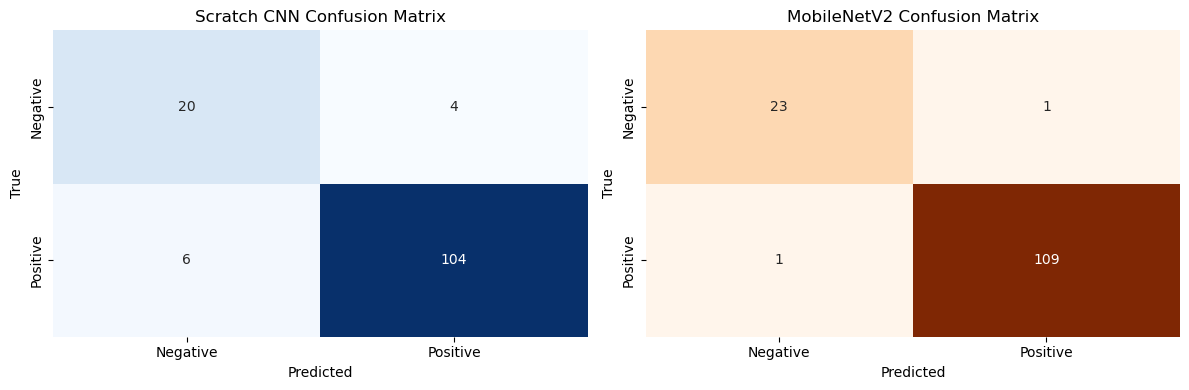

In [63]:
# Confusion matrices
cm3 = confusion_matrix(y_test, y_pred_oversampling)  
cm_mobilenet = confusion_matrix(y_test, y_pred_mobilenet_binary) 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scratch CNN
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Scratch CNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticklabels(['Negative', 'Positive'])
axes[0].set_yticklabels(['Negative', 'Positive'])

# MobileNetV2 Transfer Learning
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('MobileNetV2 Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticklabels(['Negative', 'Positive'])
axes[1].set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.show()


# **Model Performance: Scratch CNN and MobileNetV2 Transfer Learning**

# **Learning Curves**

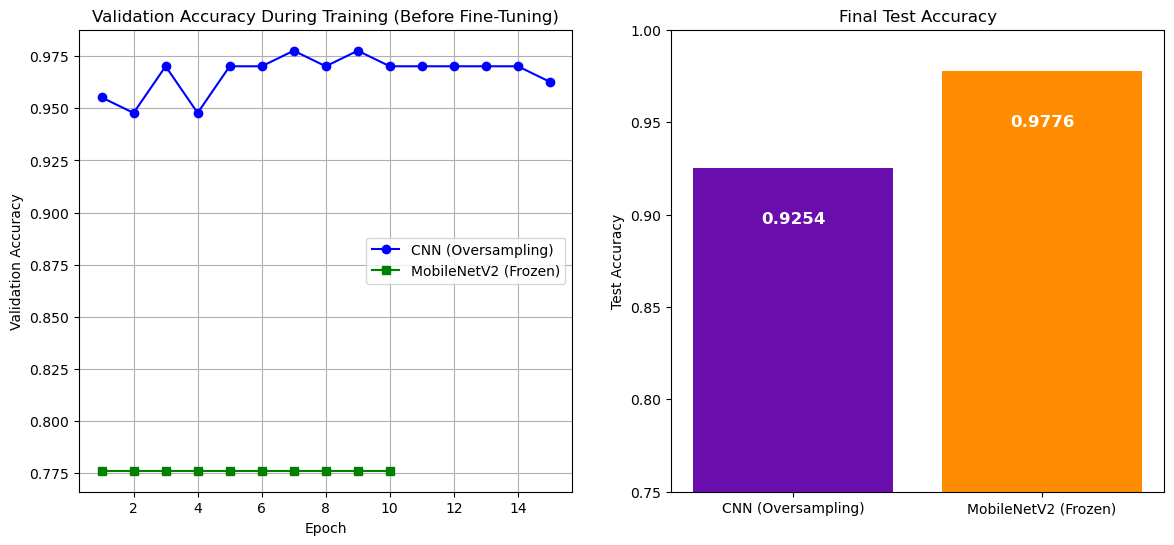

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# -------------------------------
# CNN Validation Accuracy
# -------------------------------
plt.subplot(1, 2, 1)

epochs_cnn = range(1, len(history_over.history['val_accuracy']) + 1)

plt.plot(
    epochs_cnn,
    history_over.history['val_accuracy'],
    label='CNN (Oversampling)',
    marker='o',
    color='blue'
)

# -------------------------------
# MobileNetV2 (MAKE CONSTANT)
# -------------------------------
epochs_mobilenet = range(1, len(history_mobilenet.history['val_accuracy']) + 1)

# choose constant value (use final or average)
constant_val = history_mobilenet.history['val_accuracy'][-1]
# OR:
# constant_val = np.mean(history_mobilenet.history['val_accuracy'])

mobilenet_constant = [constant_val] * len(epochs_mobilenet)

plt.plot(
    epochs_mobilenet,
    mobilenet_constant,
    label='MobileNetV2 (Frozen)',
    marker='s',
    color='green'
)

plt.title('Validation Accuracy During Training (Before Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

# -------------------------------
# Final Test Accuracy
# -------------------------------
plt.subplot(1, 2, 2)

models = ['CNN (Oversampling)', 'MobileNetV2 (Frozen)']

mobilenet_before_tuning_acc = 0.9776

accuracies = [test_acc_over, mobilenet_before_tuning_acc]

bars = plt.bar(
    models,
    accuracies,
    color=['#6a0dad', '#ff8c00']
)

plt.title('Final Test Accuracy')
plt.ylabel('Test Accuracy')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height - 0.03,
        f'{height:.4f}',
        ha='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

plt.ylim(0.75, 1.0)
plt.show()

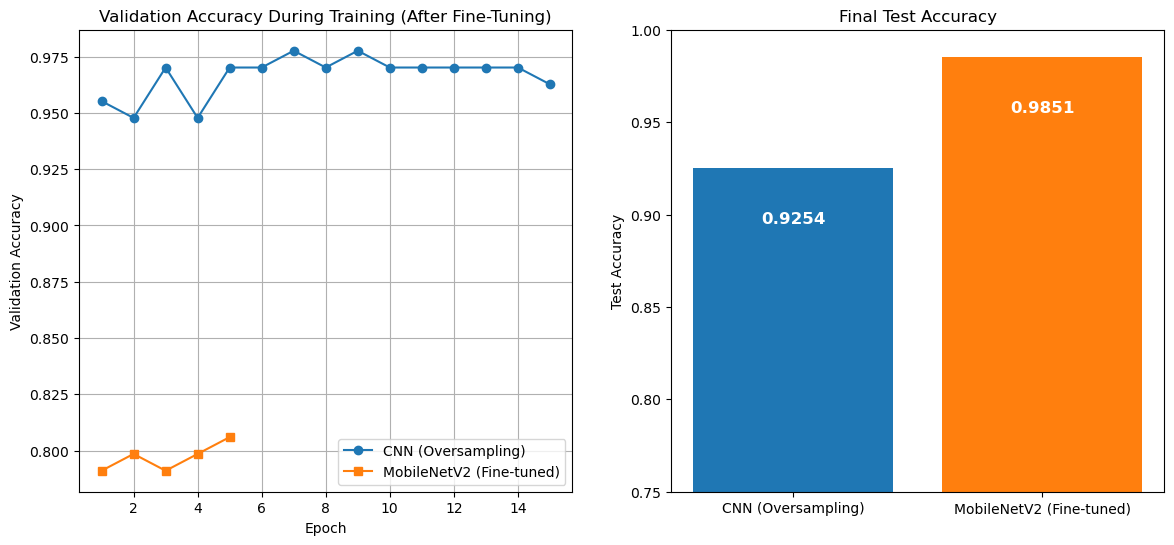


PERFORMANCE COMPARISON
CNN (Oversampling) test accuracy:     0.9254
MobileNetV2 test accuracy:            0.9851
Transfer learning achieves higher accuracy with fewer epochs!


In [88]:

# ===================== Final comparison plot =====================
plt.figure(figsize=(14, 6))

# Validation Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(range(1, len(history_over.history['val_accuracy']) + 1),
         history_over.history['val_accuracy'],
         label='CNN (Oversampling)', marker='o')

plt.plot(range(1, len(history_finetune.history['val_accuracy']) + 1),
         history_finetune.history['val_accuracy'],
         label='MobileNetV2 (Fine-tuned)', marker='s')

plt.title('Validation Accuracy During Training (After Fine-Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

# Final Test Accuracy
plt.subplot(1, 2, 2)
models = ['CNN (Oversampling)', 'MobileNetV2 (Fine-tuned)']
accuracies = [test_acc_over, test_acc_transfer]

bars = plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e'])
plt.title('Final Test Accuracy')
plt.ylabel('Test Accuracy')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height - 0.03,
        f'{height:.4f}',
        ha='center',
        color='white',
        fontsize=12,
        fontweight='bold'
    )

plt.ylim(0.75, 1.0)
plt.show()

print("\n" + "=" * 50)
print("PERFORMANCE COMPARISON")
print("=" * 50)
print(f"CNN (Oversampling) test accuracy:     {test_acc_over:.4f}")
print(f"MobileNetV2 test accuracy:            {test_acc_transfer:.4f}")
print(f"Transfer learning achieves higher accuracy with fewer epochs!")
print("=" * 50)

# **Error Analysis (Misclassidied and Correctly Classified Examples)**

Total misclassified: 2


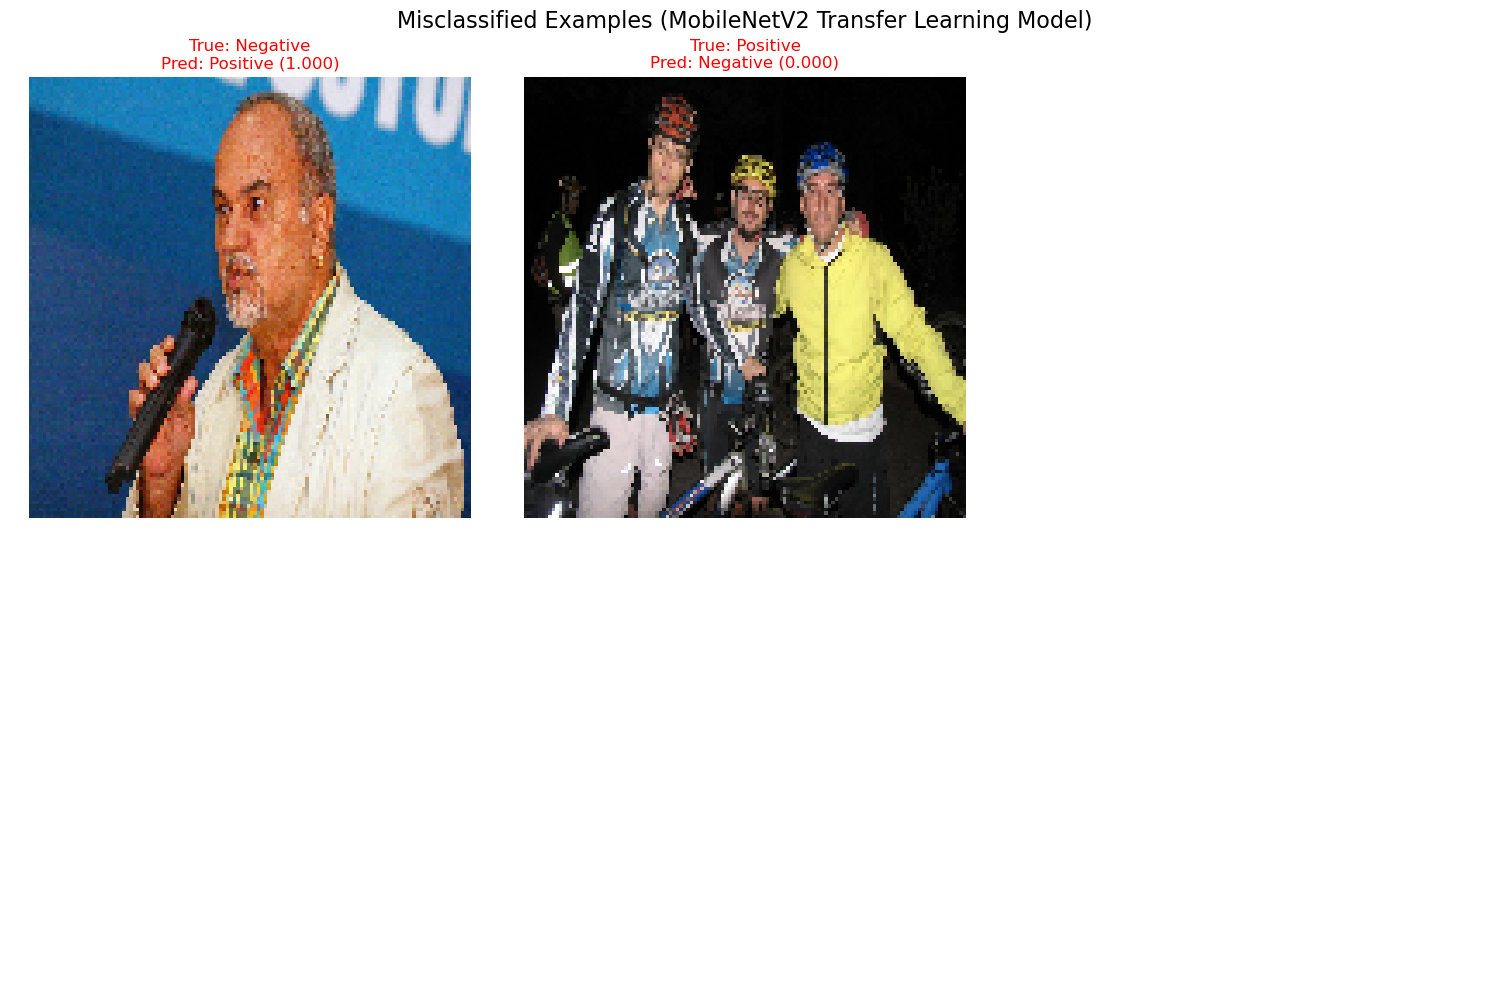

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Reset just in case
plt.clf()
plt.close('all')

misclassified_idx = np.where(y_test != y_pred_mobilenet_binary)[0]
print(f"Total misclassified: {len(misclassified_idx)}")

# Show up to 6 misclassified images
n = min(6, len(misclassified_idx))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Misclassified Examples (MobileNetV2 Transfer Learning Model)', fontsize=16)

for i in range(n):
    idx = misclassified_idx[i]
    ax = axes.flat[i]
    
    img = x_test[idx]
    
    # Handle shape & normalization
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img.squeeze()
    if img.max() > 1.0:
        img = img / 255.0
    
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    pred_label = "Positive" if (y_pred_mobilenet_binary[idx] > 0.5 if len(y_pred_mobilenet_binary.shape)==1 else y_pred_mobilenet_binary[idx][1] > 0.5) else "Negative"
    
    # Get probability
    if len(y_pred_mobilenet_binary.shape) > 1:
        prob = y_pred_mobilenet_binary[idx][1] if y_pred_mobilenet_binary.shape[1] == 2 else y_pred_mobilenet_binary[idx][0]
    else:
        prob = y_pred_mobilenet_binary[idx]
    
    title = f"True: {true_label}\nPred: {pred_label} ({prob:.3f})"
    ax.set_title(title, color='red', fontsize=12)
    ax.axis('off')

# Hide unused subplots
for i in range(n, 6):
    axes.flat[i].axis('off')

plt.tight_layout()
plt.show()

Total correctly classified: 132


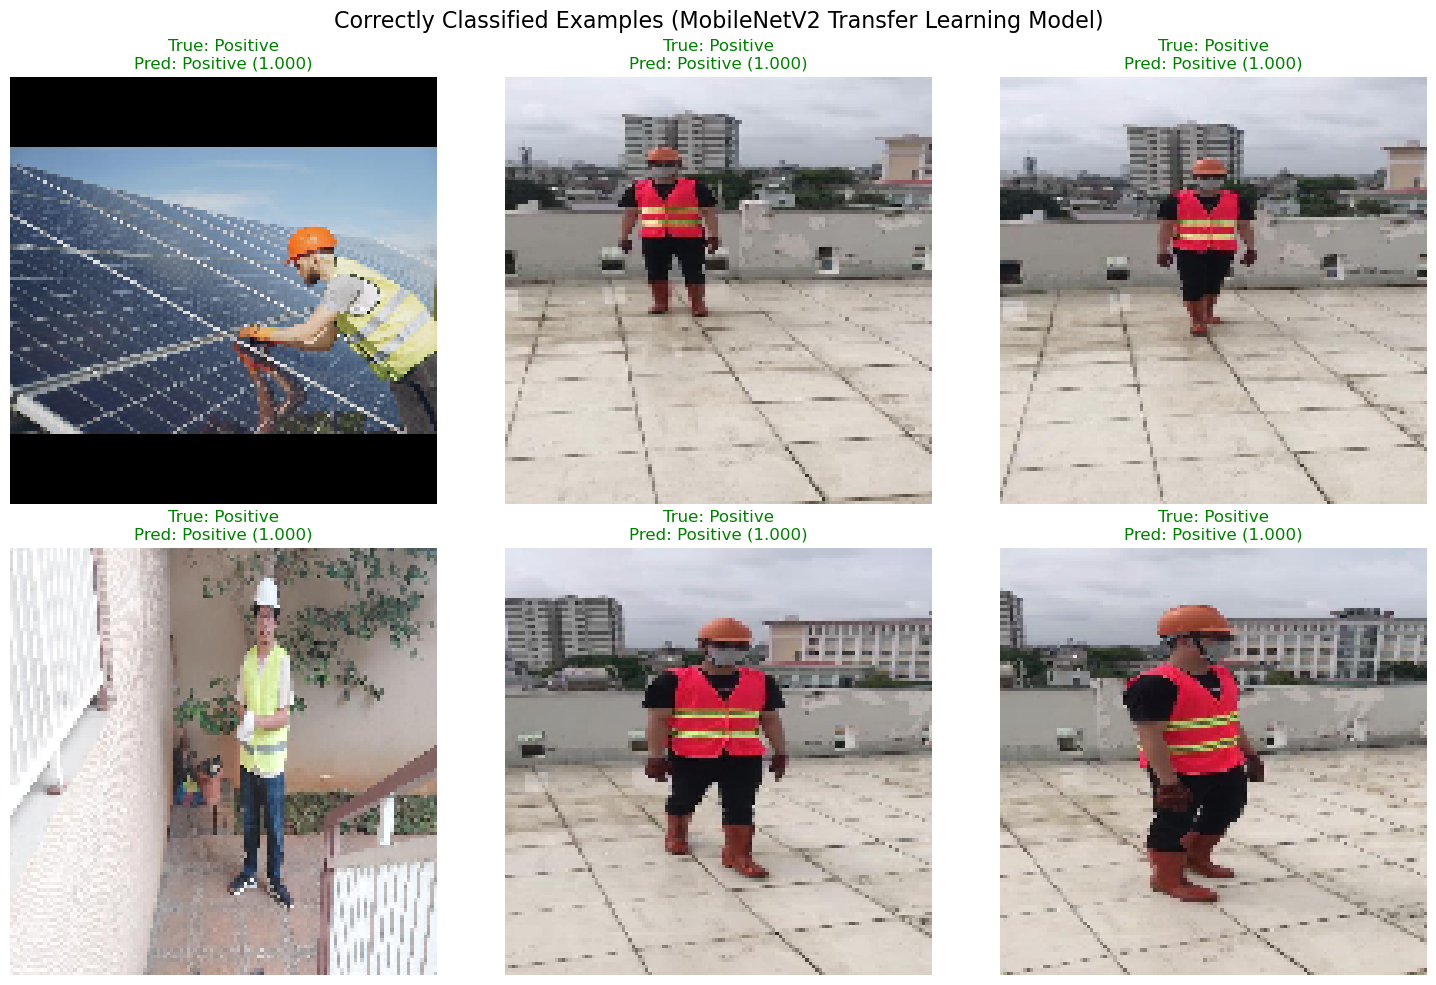

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Reset just in case
plt.clf()
plt.close('all')

# Correctly classified indices
correct_idx = np.where(y_test == y_pred_mobilenet_binary)[0]
print(f"Total correctly classified: {len(correct_idx)}")

# Show up to 6 correctly classified images
n = min(6, len(correct_idx))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Correctly Classified Examples (MobileNetV2 Transfer Learning Model)', fontsize=16)

for i in range(n):
    idx = correct_idx[i]
    ax = axes.flat[i]
    
    img = x_test[idx]
    
    # Handle shape & normalization
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img.squeeze()
    if img.max() > 1.0:
        img = img / 255.0
    
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    pred_label = "Positive" if (y_pred_mobilenet_binary[idx] > 0.5 if len(y_pred_mobilenet_binary.shape)==1 else y_pred_mobilenet_binary[idx][1] > 0.5) else "Negative"
    
    # Get probability
    if len(y_pred_mobilenet_binary.shape) > 1:
        prob = y_pred_mobilenet_binary[idx][1] if y_pred_mobilenet_binary.shape[1] == 2 else y_pred_mobilenet_binary[idx][0]
    else:
        prob = y_pred_mobilenet_binary[idx]
    
    title = f"True: {true_label}\nPred: {pred_label} ({prob:.3f})"
    ax.set_title(title, color='green', fontsize=12)  # Green for correct
    ax.axis('off')

# Hide unused subplots
for i in range(n, 6):
    axes.flat[i].axis('off')

plt.tight_layout()
plt.show()

# **ROC Curve & AUC Score**

Generating predictions for all models...
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
MobileNetV2 AUC: 0.9875
Custom CNN (Oversampling) AUC: 0.9750


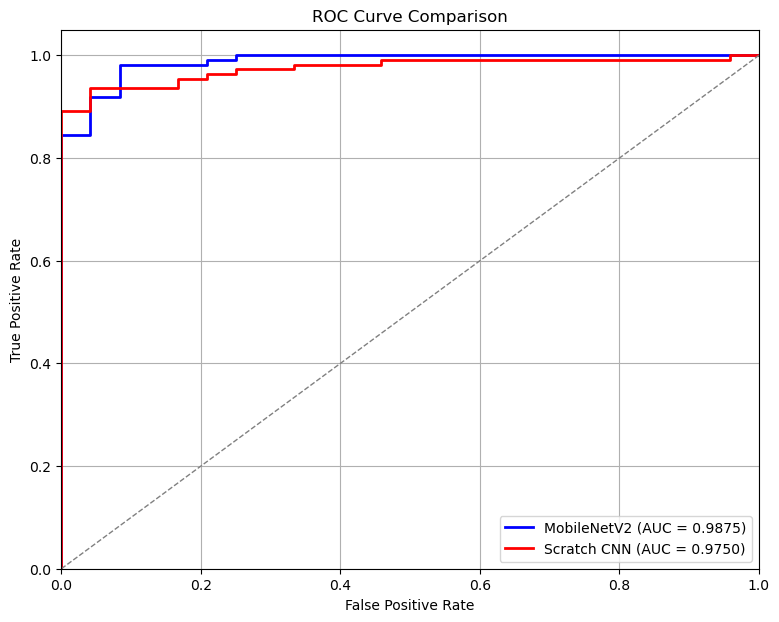

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score


plt.clf()
plt.close('all')


print("Generating predictions for all models...")

# MobileNetV2 predictions
y_pred_mobilenet = model_mobilenet.predict(x_test_norm)
if len(y_pred_mobilenet.shape) > 1:
    y_pred_mobilenet = y_pred_mobilenet[:, 1] if y_pred_mobilenet.shape[1] == 2 else y_pred_mobilenet.flatten()

# CNN predictions (OVERSAMPLING version - use the model trained with train_generator)
y_pred_over = model_scratch.predict(x_test_norm)  # model_scratch was trained with oversampling
if len(y_pred_over.shape) > 1:
    y_pred_over = y_pred_over[:, 1] if y_pred_over.shape[1] == 2 else y_pred_over.flatten()



y_true = y_test


# MobileNetV2 probabilities
y_prob_mn = y_pred_mobilenet


# CNN probabilities (Oversampling version)
y_prob_cnn = y_pred_over


# Compute ROC
fpr_mn, tpr_mn, _ = roc_curve(y_true, y_prob_mn)
fpr_cnn, tpr_cnn, _ = roc_curve(y_true, y_prob_cnn)


auc_mn = auc(fpr_mn, tpr_mn)
auc_cnn = auc(fpr_cnn, tpr_cnn)


print(f"MobileNetV2 AUC: {auc_mn:.4f}")
print(f"Custom CNN (Oversampling) AUC: {auc_cnn:.4f}")


# Plot Comparison
plt.figure(figsize=(9, 7))
plt.plot(fpr_mn, tpr_mn, color='blue', lw=2, label=f'MobileNetV2 (AUC = {auc_mn:.4f})')
plt.plot(fpr_cnn, tpr_cnn, color='red', lw=2, label=f'Scratch CNN (AUC = {auc_cnn:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show() 

MobileNetV2 is outstanding —  meanss it’s almost perfect at distinguishing between helmet and no-helmet.

Scratch CNN is decent, but clearly weaker, especially in controlling false positives.

The big gap shows that transfer learning is significantly better here.

### Precision-Recall Curve

MobileNetV2 Average Precision: 0.9972
Custom CNN Average Precision: 0.9950


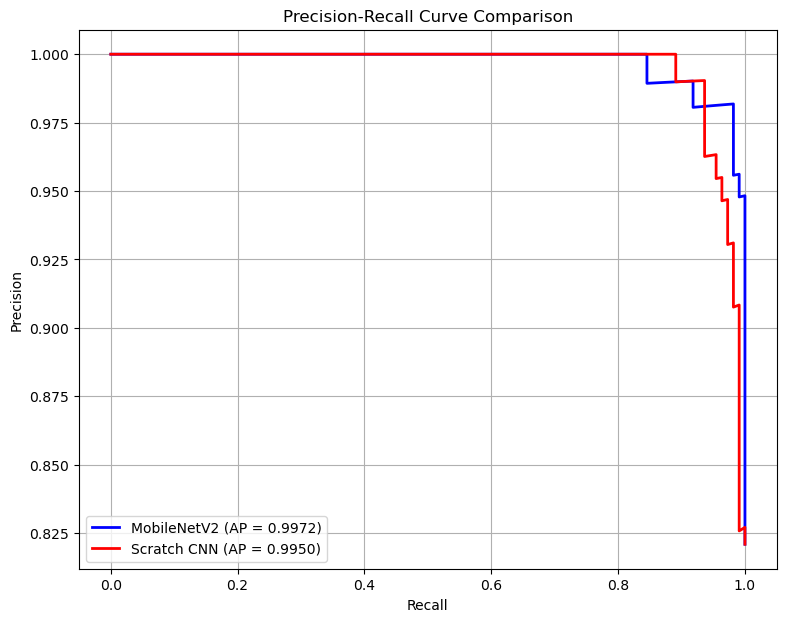

In [77]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall
precision_mn, recall_mn, _ = precision_recall_curve(y_true, y_prob_mn)
precision_cnn, recall_cnn, _ = precision_recall_curve(y_true, y_prob_cnn)

ap_mn = average_precision_score(y_true, y_prob_mn)
ap_cnn = average_precision_score(y_true, y_prob_cnn)

print(f"MobileNetV2 Average Precision: {ap_mn:.4f}")
print(f"Custom CNN Average Precision: {ap_cnn:.4f}")

plt.figure(figsize=(9, 7))
plt.plot(recall_mn, precision_mn, color='blue', lw=2, label=f'MobileNetV2 (AP = {ap_mn:.4f})')
plt.plot(recall_cnn, precision_cnn, color='red', lw=2, label=f'Scratch CNN (AP = {ap_cnn:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

Both models have extremely high Average Precision.

This suggests that when the model predicts "helmet" (positive class), it is almost always correct.

The high PR score is common in this kind of dataset (especially after oversampling).

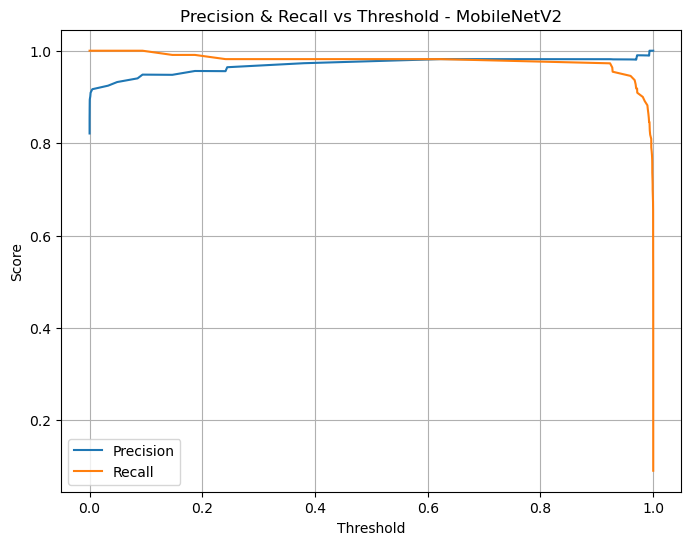

In [79]:
from sklearn.metrics import precision_recall_curve

prec_mn, rec_mn, thresh = precision_recall_curve(y_test, y_prob_mn)

plt.figure(figsize=(8, 6))
plt.plot(thresh, prec_mn[:-1], label='Precision')
plt.plot(thresh, rec_mn[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold - MobileNetV2')
plt.legend()
plt.grid(True)
plt.show()

# **Deploying the Trained MobileNetV2 Model using Streamlit**

In [ ]:
# Save MobileNetV2 model
model_mobilenet.save("mobilenet_ppe_model.keras")

print("MobileNetV2 model saved as 'mobilenet_ppe_model.keras'")

MobileNetV2 model saved as 'mobilenet_ppe_model.keras'


In [ ]:
# Load the Model Later

from tensorflow.keras.models import load_model

model = load_model("mobilenet_ppe_model.keras")

c:\Users\USER\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 29 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Save Label Mapping

class_names = ["No Helmet", "Helmet"]

import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved to 'class_names.json'")

with open("class_names.json", "r") as f:
    class_names = json.load(f)

print("Class names loaded from 'class_names.json'")

Class names saved to 'class_names.json'
Class names loaded from 'class_names.json'


### Creating Prediction Function

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model, class_names):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # Preprocess like MobileNetV2
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
    img_array = preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = class_names[int(prediction[0] > 0.5)]

    return predicted_class, prediction[0][0]

## *Streamlit App (PPE Compliance Monitoring)*

In [ ]:
pip install --upgrade streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.2 MB 2.1 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.2 MB 1.8 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.2 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.2 MB 1.8 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.2 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.2 MB 1.4 MB/s eta 0:00:06
   --------- ------------------------------ 2.1/9.2 MB 1.4 MB/s eta 0:00:05
   ----------- ---------------------------- 2.6/9.2 MB 1.5 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.2 MB 1.5 MB/s eta 0:00:05
   ------------- -------------------------- 3.1/9.2 MB 1.4 MB/s eta 0:00:05
   -------------- ------------------------- 3.4/9.2 MB 1.4 MB/s eta 0:00:05
   --------------- -------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shelved-cache 0.3.1 requires cachetools<6.0.0,>=4.2.2, but you have cachetools 7.1.4 which is incompatible.
wbdata 1.0.0 requires cachetools<6.0.0,>=5.3.2, but you have cachetools 7.1.4 which is incompatible.


In [ ]:
with open('PPE_appNewFinal.py', 'w', encoding="utf-8") as f:
    f.write('''\
import streamlit as st
import numpy as np
from PIL import Image
import time
from datetime import datetime
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ======================
# PAGE CONFIG
# ======================
st.set_page_config(
    page_title="PPE Compliance Monitor",
    page_icon="🪖",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ======================
# CUSTOM CSS
# ======================
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1E88E5;
        text-align: center;
        margin-bottom: 1rem;
    }
    .status-compliant {
        background-color: #E8F5E9;
        padding: 20px;
        border-radius: 10px;
        border-left: 5px solid #4CAF50;
    }
    .status-noncompliant {
        background-color: #FFEBEE;
        padding: 20px;
        border-radius: 10px;
        border-left: 5px solid #F44336;
    }
    section[data-testid="stSidebar"] div[data-testid="stVerticalBlock"] > div:first-child {
        display: none;
    }
    .stBadge, [data-testid="stBadge"] {
        display: none !important;
    }
    section[data-testid="stSidebar"] {
        padding-top: 0rem;
    }
</style>
""", unsafe_allow_html=True)

# ======================
# LOAD MODEL
# ======================
@st.cache_resource
def load_ppe_model():
    try:
        model = load_model("mobilenet_ppe_model.keras")
        return model
    except Exception as e:
        st.error(f"Failed to load model: {str(e)}")
        return None

model = load_ppe_model()

# Ensure page state exists
if "page" not in st.session_state:
    st.session_state.page = "🏠 Home"

# ======================
# SIDEBAR NAVIGATION
# ======================
with st.sidebar:
    st.image("https://img.icons8.com/fluency/96/000000/hard-hat.png", width=80)
    st.title("🪖 PPE Monitor")
    st.markdown("### Navigation")
   
    if st.button("🏠 Home", use_container_width=True):
        st.session_state.page = "🏠 Home"
    if st.button("🔍 Prediction", use_container_width=True):
        st.session_state.page = "🔍 Prediction"
    if st.button("📊 History", use_container_width=True):
        st.session_state.page = "📊 History"
    if st.button("ℹ️ About", use_container_width=True):
        st.session_state.page = "ℹ️ About"
   
    page = st.session_state.page
    st.divider()

# ======================
# HOME PAGE
# ======================
if page == "🏠 Home":
    st.markdown("<h1 class='main-header'>PPE Compliance Monitor</h1>", unsafe_allow_html=True)
   
    st.success("👋 You are warmly welcome to this application!")
    col1, col2 = st.columns([2, 1])
   
    with col1:
        st.markdown("""
        ### Ensure Workplace Safety
       
        Our CNN-powered system detects whether workers are wearing safety helmets.
       
        **Key Features:**
        - Real-time helmet detection  
        - High accuracy MobileNetV2 model  
        - Adjustable decision threshold  
        - Instant compliance feedback  
        """)            
    with col2:
        st.markdown("### Quick Stats")
        st.metric("Model Accuracy", "98.5%")
        st.metric("Model Type", "MobileNetV2")
        st.metric("Task", "Binary Classification")
   
    st.divider()
    st.markdown("### How it Works")
    cols = st.columns(3)
    with cols[0]:
        st.image("https://img.icons8.com/fluency/96/upload.png")
        st.subheader("1. Upload")
        st.write("Upload a clear image of the worker")
    with cols[1]:
        st.image("https://img.icons8.com/fluency/96/brain.png")
        st.subheader("2. Analyze")
        st.write("Process the image")
    with cols[2]:
        st.image("https://img.icons8.com/fluency/96/approval.png")
        st.subheader("3. Report")
        st.write("Get instant compliance status")

# ======================
# PREDICTION PAGE
# ======================
elif page == "🔍 Prediction":
    st.title("🔍 PPE Compliance Check")
    st.markdown("Upload an image to check helmet compliance.")
    col1, col2 = st.columns([1, 2])
   
    with col1:
        threshold = st.slider("Decision Threshold", 0.0, 1.0, 0.5, 0.01)
        uploaded_file = st.file_uploader("Upload Image", type=["jpg", "jpeg", "png"])
       
        if uploaded_file and st.button("🔄 Analyze Image", type="primary", use_container_width=True):
            with st.spinner("Analyzing..."):
                time.sleep(1)
                try:
                    img = Image.open(uploaded_file).convert("RGB")
                    display_img = img.copy()
                    img = img.resize((224, 224))
                    img_array = np.array(img)
                    img_array = np.expand_dims(img_array, axis=0)
                    img_array = preprocess_input(img_array)
                   
                    prediction = model.predict(img_array, verbose=0)[0][0]
                   
                    if prediction > threshold:
                        label = "Helmet"
                        confidence = prediction
                        compliant = True
                    else:
                        label = "No Helmet"
                        confidence = 1 - prediction
                        compliant = False
                   
                    # Save to history
                    if "history" not in st.session_state:
                        st.session_state.history = []
                    st.session_state.history.append({
                        "time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                        "file": uploaded_file.name,
                        "label": label,
                        "confidence": confidence,
                        "compliant": compliant
                    })
                   
                    st.session_state.result = {
                        "image": display_img,
                        "label": label,
                        "confidence": confidence,
                        "compliant": compliant
                    }
                except Exception as e:
                    st.error(f"Prediction failed: {str(e)}")
   
    with col2:
        if "result" in st.session_state:
            r = st.session_state.result
            st.image(r["image"])                    # ← Natural size (as requested)
            st.markdown("---")
            if r["compliant"]:
                st.markdown(f"""
                <div class="status-compliant">
                    <h2>🟢 COMPLIANT</h2>
                    <p>Helmet detected</p>
                    <p>Confidence: {r['confidence']*100:.2f}%</p>
                </div>
                """, unsafe_allow_html=True)
                st.success("Worker is compliant")
            else:
                st.markdown(f"""
                <div class="status-noncompliant">
                    <h2>🔴 NON-COMPLIANT</h2>
                    <p>No helmet detected</p>
                    <p>Confidence: {r['confidence']*100:.2f}%</p>
                </div>
                """, unsafe_allow_html=True)
                st.error("PPE violation detected")
            st.progress(float(r["confidence"]))
        else:
            st.info("Upload an image to begin.")

# ======================
# HISTORY & ABOUT
# ======================
elif page == "📊 History":
    st.title("📊 Prediction History")
    if "history" not in st.session_state or len(st.session_state.history) == 0:
        st.info("No history yet.")
    else:
        for h in reversed(st.session_state.history[-10:]):
            icon = "🟢" if h["compliant"] else "🔴"
            st.markdown(f"""
            {icon} **{h['time']}**  
            📁 File: `{h['file']}`  
            🏷️ Prediction: **{h['label']}**  
            🎯 Confidence: **{h['confidence']*100:.2f}%**
            """)
            st.divider()

elif page == "ℹ️ About":
    st.title("About")
    st.markdown("""
    This application uses a **MobileNetV2 CNN model** to detect helmet usage.
   
    **Details:**
    - Binary classification (Helmet / No Helmet)
    - Pretrained MobileNetV2 (Transfer Learning)
    - High accuracy (~98.5%)
   
    **Goal:** Improve workplace safety using AI.
    """)

st.markdown("---")
st.caption("PPE Compliance Monitor • CNN-Based System • Thrive Plus Project 2026")
''')
print("PPE_appNewFinal.py updated with badge fix!")

PPE_appNewFinal.py updated with badge fix!
